# Customer Segmentation using K-Means Clustering

## 1. Title of the Project
**Customer Segmentation using K-Means Clustering Algorithm**

## 2. Objective
The main objectives of this project are:
* Group customers based on similar characteristics
* Identify different types of customers
* Help businesses improve marketing strategies
* Increase sales and customer satisfaction

## 3. Problem Statement
Businesses often have large numbers of customers, but:
* Treat all customers the same
* Cannot identify high-value customers
* Waste marketing resources

This project aims to segment customers into groups using clustering techniques.

## 4. Proposed Solution
Develop a system that:
* Takes customer data (income, spending, age, etc.)
* Applies clustering algorithms
* Divides customers into meaningful groups

Example groups:
* High spenders
* Low spenders
* Budget customers
* Premium customers

## 5. Technologies Used
* **Programming Language:** Python
* **Libraries:**
    * Pandas (Data handling)
    * NumPy (Numerical operations)
    * Matplotlib / Seaborn (Visualization)
    * Scikit-learn (Clustering algorithms)
* **Tools:** Jupyter Notebook

## 6. Dataset Description
| Feature Name | Description |
|--------------|-------------|
| CustomerID   | Unique ID |
| Age          | Customer age |
| Gender       | Male/Female |
| Annual Income (k$) | Income in thousands |
| Spending Score (1-100) | Score based on behavior |
| Purchase_Frequency | Number of purchases |

## 7. Implementation - Step 1: Data Collection
We will start by importing the necessary libraries and loading the dataset.

In [ ]:
pip install numpy pandas matplotlib sklearn warnings

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv('data/Mall_Customers.csv')

# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Purchase_Frequency
0,1,Male,19,15,39,5
1,2,Male,21,15,81,12
2,3,Female,20,16,6,2
3,4,Female,23,16,77,15
4,5,Female,31,17,40,6


## Step 2: Data Preprocessing
We check for missing values and basic statistics.

In [3]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Basic info
df.info()

# Statistical summary
df.describe()

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Purchase_Frequency        0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
 5   Purchase_Frequency      200 non-null    int64
dtypes: int64(5), str(1)
memory usage: 9.5 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Purchase_Frequency
count,200.000000,200.000000,200.000000,200.000000,200.00000
mean,100.500000,38.755000,60.560000,50.200000,9.90500
std,57.879185,14.039248,26.264721,25.823522,5.12026
min,1.000000,18.000000,15.000000,1.000000,1.00000
25%,50.750000,28.000000,41.500000,34.750000,6.00000
50%,100.500000,36.000000,61.500000,50.000000,10.00000
75%,150.250000,49.000000,78.000000,73.000000,14.00000
max,200.000000,70.000000,137.000000,99.000000,20.00000


## Data Exploration
We visualize the relationships between Age, Annual Income, Spending Score, and Purchase Frequency to understand the data distribution.

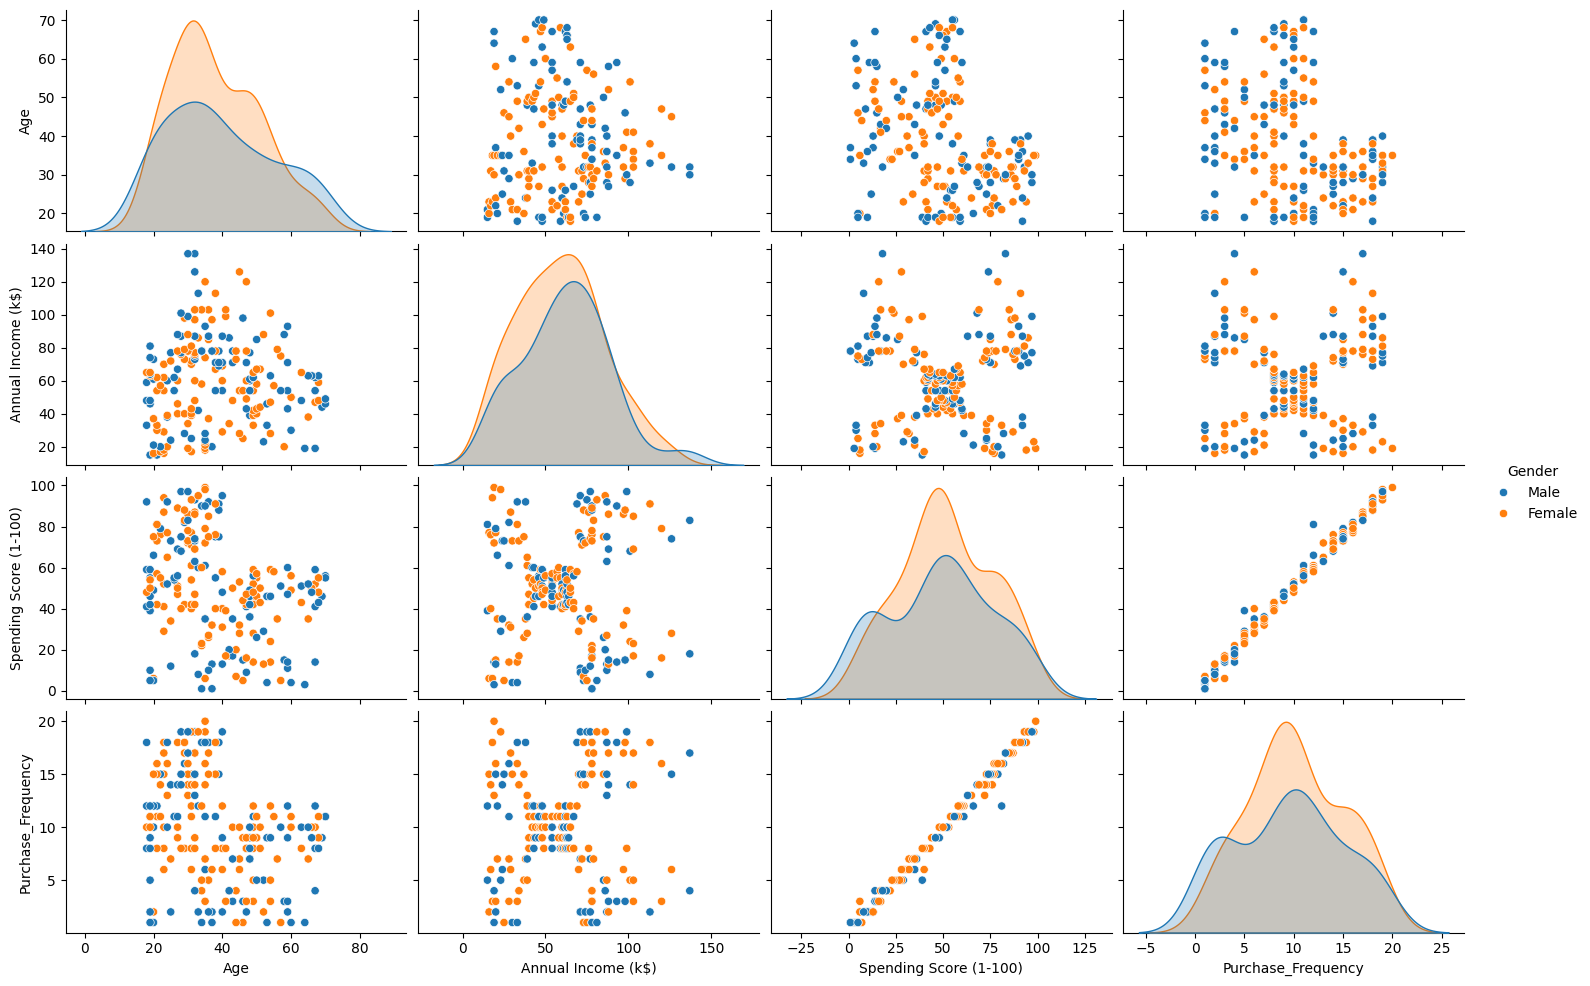

In [4]:
sns.pairplot(df.drop('CustomerID', axis=1), hue='Gender', aspect=1.5)
plt.show()

## Step 3: Feature Selection
For visualization purposes, we will select `Annual Income (k$)` and `Spending Score (1-100)` for clustering.

In [5]:
X = df.iloc[:, [3, 4]].values
print("Selected features (first 5 rows):\n", X[:5])

Selected features (first 5 rows):
 [[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


## Step 4: Finding Optimal Clusters (Elbow Method)
We use the Within-Cluster Sum of Squares (WCSS) to find the elbow point.

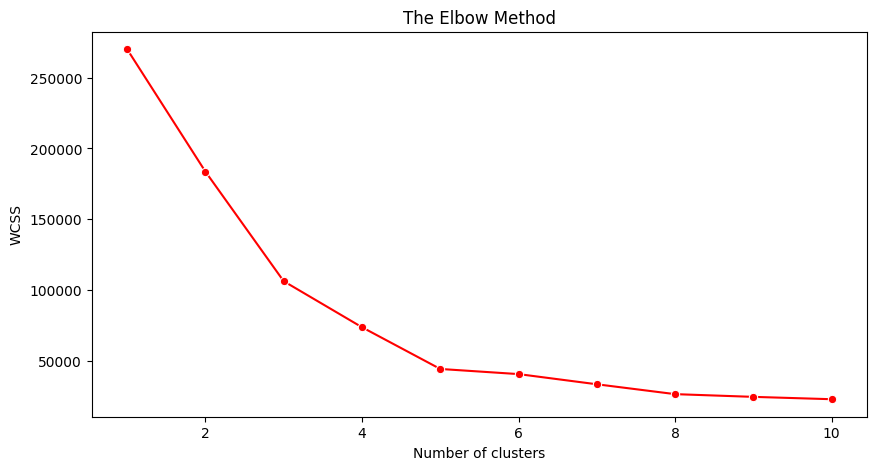

In [6]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, 11), y=wcss, marker='o', color='red')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Step 5 & 6: Apply K-Means and Model Training
Based on the elbow plot, the optimal number of clusters is **5** (where the curve bends significantly).

In [7]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
Y = kmeans.fit_predict(X)

print("Cluster labels for each customer assigned.")

Cluster labels for each customer assigned.


## Step 7: Visualization of Clusters

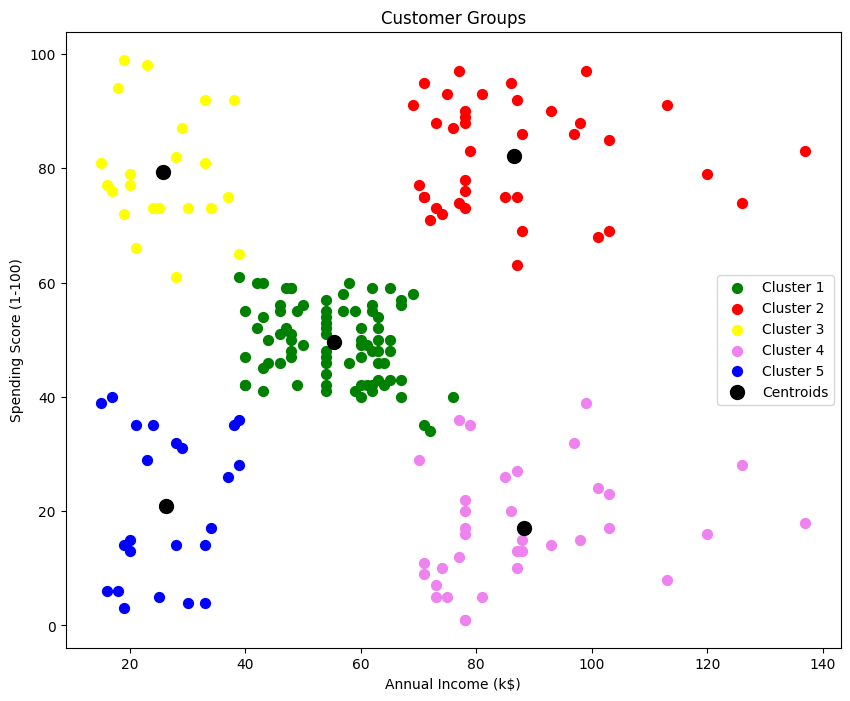

In [8]:
plt.figure(figsize=(10, 8))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], s = 50, c = 'green', label = 'Cluster 1')
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], s = 50, c = 'red', label = 'Cluster 2')
plt.scatter(X[Y == 2, 0], X[Y == 2, 1], s = 50, c = 'yellow', label = 'Cluster 3')
plt.scatter(X[Y == 3, 0], X[Y == 3, 1], s = 50, c = 'violet', label = 'Cluster 4')
plt.scatter(X[Y == 4, 0], X[Y == 4, 1], s = 50, c = 'blue', label = 'Cluster 5')

# Plotting the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'black', label = 'Centroids')

plt.title('Customer Groups')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## Step 8: Interpretation & Analysis

Based on the visualization, we can define the clusters as:
* **Cluster 1 (Green):** Average Income, Average Spending
* **Cluster 2 (Red):** High Income, Low Spending (**Target: Premium offers**)
* **Cluster 3 (Yellow):** Low Income, High Spending (**Target: Budget offers**)
* **Cluster 4 (Violet):** Low Income, Low Spending (**Standard customers**)
* **Cluster 5 (Blue):** High Income, High Spending (**Target: Luxury/Loyalty programs**)

## 14. Conclusion
Customer segmentation helps businesses:
* Identify valuable customers
* Improve marketing strategies
* Make data-driven decisions

Clustering techniques like K-Means provide efficient and scalable solutions.